# RouteFinder on Solomon VRPTW

Train a `RouteFinderPolicy` for 3 epochs on 50-customer synthetic VRPTW data, then evaluate it on Solomon RC instances from the dataset folder and compare against OR-Tools.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from tensordict import TensorDict
import pandas as pd
import torch
from IPython.display import display
from rl4co.utils.trainer import RL4COTrainer

# sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.heuristics.ortools_solver import ORToolsVRPTWSolver
from dvrptw_bench.metrics.objective import total_distance
from dvrptw_bench.rl.routefinder_adapter import instance_to_routefinder_td, routefinder_actions_to_solution
from dvrptw_bench.rl.mtvrp_solomon_generator import SolomonMTVRPGenerator
from dvrptw_bench.rl.mtvrp_solomon_generator import MTVRPGenerator
from dvrptw_bench.viz.route_plot import plot_routes
from dvrptw_bench.common.typing import VRPTWInstance
from routefinder.envs.mtvrp import MTVRPEnv, MTVRPGenerator
from routefinder.models import RouteFinderBase, RouteFinderPolicy
from routefinder.utils import evaluate as evaluate_routefinder

In [2]:
DATASET_ROOT = Path('../dataset/solomon_rc100')
RC_DATASET_ROOT = Path('../dataset/solomon_rc100')
C_DATASET_ROOT = Path('../dataset/solomon_c100')
OUTPUT_ROOT = Path('../outputs/notebook_routefinder')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CUSTOMERS = 50
NUM_EPOCHS = 3
BATCH_SIZE = 256
TRAIN_DATA_SIZE = 100_000
VAL_DATA_SIZE = 10_000
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-6
NUM_AUGMENT = 8
ORTOOLS_TIME_LIMIT_S = 3
MAX_EVAL_INSTANCES = 5  # set to None to evaluate all RC instances

if torch.cuda.is_available():
    device = torch.device('cuda')
    accelerator = 'gpu'
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
    accelerator = 'mps'
else:
    device = torch.device('cpu')
    accelerator = 'cpu'

print('Device:', device)
print('Dataset root:', DATASET_ROOT.resolve())
print('Output root:', OUTPUT_ROOT.resolve())


Device: mps
Dataset root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/dataset/solomon_rc100
Output root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/outputs/notebook_routefinder


In [3]:
def instance_to_generator_td(instance, num_customers):
    coords = [(instance.depot.x, instance.depot.y)] + [
        (c.x, c.y) for c in instance.customers
    ]

    locs = torch.tensor(coords, dtype=torch.float32)

    # enforce size
    assert locs.shape[0] >= num_customers + 1
    locs = locs[: num_customers + 1]

    # normalize
    locs = locs / 100.0

    return locs
rcInstances = [parse_solomon(instance, max_customers=NUM_CUSTOMERS) for instance in find_rc_instances(RC_DATASET_ROOT)]
cInstances = [parse_solomon(instance, max_customers=NUM_CUSTOMERS) for instance in find_rc_instances(C_DATASET_ROOT)]
generatorSolomonInstances = [instance_to_generator_td(instance, NUM_CUSTOMERS) for instance in rcInstances] + [instance_to_generator_td(instance, NUM_CUSTOMERS) for instance in cInstances]

In [ ]:

generator = SolomonMTVRPGenerator(num_loc=NUM_CUSTOMERS, variant_preset='vrptw', solomon_instances=generatorSolomonInstances)
env = MTVRPEnv(generator, check_solution=False)
policy = RouteFinderPolicy(env_name=env.name).to(device)
model = RouteFinderBase(
    env,
    policy,
    batch_size=BATCH_SIZE,
    train_data_size=TRAIN_DATA_SIZE,
    val_data_size=VAL_DATA_SIZE,
    optimizer_kwargs={'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
)

trainer = RL4COTrainer(
    max_epochs=NUM_EPOCHS,
    accelerator=accelerator,
    devices=1,
    logger=None,
    precision='32-true',
)

trainer.fit(model)


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to poten

Generating locations for batch size: 100000 [100000]


val_file not set. Generating dataset instead
test_file not set. Generating dataset instead


Generating locations for batch size: 10000 [10000]
Generating locations for batch size: 10000 [10000]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ env      │ MTVRPEnv          │      0 │ train │     0 │
│ 1 │ policy   │ RouteFinderPolicy │  1.3 M │ train │     0 │
│ 2 │ baseline │ SharedBaseline    │      0 │ train │     0 │
└───┴──────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 112                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/ut
ilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a 
bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to 
improve performance.

In [ ]:
instance_paths = find_rc_instances(DATASET_ROOT)
assert instance_paths, f'No RC instances found under {DATASET_ROOT.resolve()}'

if MAX_EVAL_INSTANCES is not None:
    instance_paths = instance_paths[:MAX_EVAL_INSTANCES]

instances = [parse_solomon(path, max_customers=NUM_CUSTOMERS) for path in instance_paths]
print('Loaded instances:', [instance.instance_id for instance in instances])


def solve_with_routefinder(instance, num_augment=NUM_AUGMENT):
    t0 = time.perf_counter()
    td = instance_to_routefinder_td(instance, normalize_coords=True).to(device)
    td_reset = env.reset(td)
    model.to(device).eval()

    with torch.inference_mode():
        if num_augment > 1:
            out = evaluate_routefinder(model, td_reset.clone(), num_augment=num_augment)
            actions = out.get('best_aug_actions', out.get('best_multistart_actions', out.get('actions')))
        else:
            out = model.policy(
                td_reset.clone(),
                env,
                phase='test',
                decode_type='greedy',
                return_actions=True,
            )
            actions = out['actions']

    solution = routefinder_actions_to_solution(actions, instance, strategy='routefinder')
    solution.total_distance = total_distance(instance, solution)
    solution.solve_time_s = time.perf_counter() - t0
    solution.details.update({'num_augment': num_augment})
    return solution


AssertionError: No RC instances found under /fyp-vrp/dataset/solomon_rc100

In [ ]:
ortools = ORToolsVRPTWSolver()
routefinder_solutions = {}
ortools_solutions = {}
rows = []

for instance in instances:
    rf_solution = solve_with_routefinder(instance)
    or_solution = ortools.solve(instance, time_limit_s=ORTOOLS_TIME_LIMIT_S)

    routefinder_solutions[instance.instance_id] = rf_solution
    ortools_solutions[instance.instance_id] = or_solution

    gap_pct = 100.0 * (rf_solution.total_distance - or_solution.total_distance) / or_solution.total_distance
    rows.append(
        {
            'instance_id': instance.instance_id,
            'n_customers': instance.n_customers,
            'routefinder_distance': rf_solution.total_distance,
            'ortools_distance': or_solution.total_distance,
            'gap_to_ortools_pct': gap_pct,
            'routefinder_routes': len([r for r in rf_solution.routes if r.node_ids]),
            'ortools_routes': len([r for r in or_solution.routes if r.node_ids]),
            'routefinder_time_s': rf_solution.solve_time_s,
            'ortools_time_s': or_solution.solve_time_s,
        }
    )

results_df = pd.DataFrame(rows).sort_values('gap_to_ortools_pct').reset_index(drop=True)
results_df[['routefinder_distance', 'ortools_distance', 'gap_to_ortools_pct', 'routefinder_time_s', 'ortools_time_s']] = results_df[[
    'routefinder_distance', 'ortools_distance', 'gap_to_ortools_pct', 'routefinder_time_s', 'ortools_time_s'
]].round(3)

display(results_df)
results_df.to_csv(OUTPUT_ROOT / 'routefinder_vs_ortools.csv', index=False)
print('Saved table to', OUTPUT_ROOT / 'routefinder_vs_ortools.csv')


,instance_id,n_customers,routefinder_distance,ortools_distance,gap_to_ortools_pct,routefinder_routes,ortools_routes,routefinder_time_s,ortools_time_s
0,RC201.txt,50,2994.0,675.0,343.556,23,5,1.799,4.024
1,RC203.txt,50,2591.0,546.0,374.542,24,4,0.367,3.003
2,RC205.txt,50,3180.0,619.0,413.732,30,5,0.524,3.000
3,RC202.txt,50,3233.0,605.0,434.380,32,5,0.398,3.000
4,RC204.txt,50,2877.0,436.0,559.862,25,3,0.359,3.001


Saved table to ../outputs/notebook_routefinder/routefinder_vs_ortools.csv


NameError: name 'results_df' is not defined

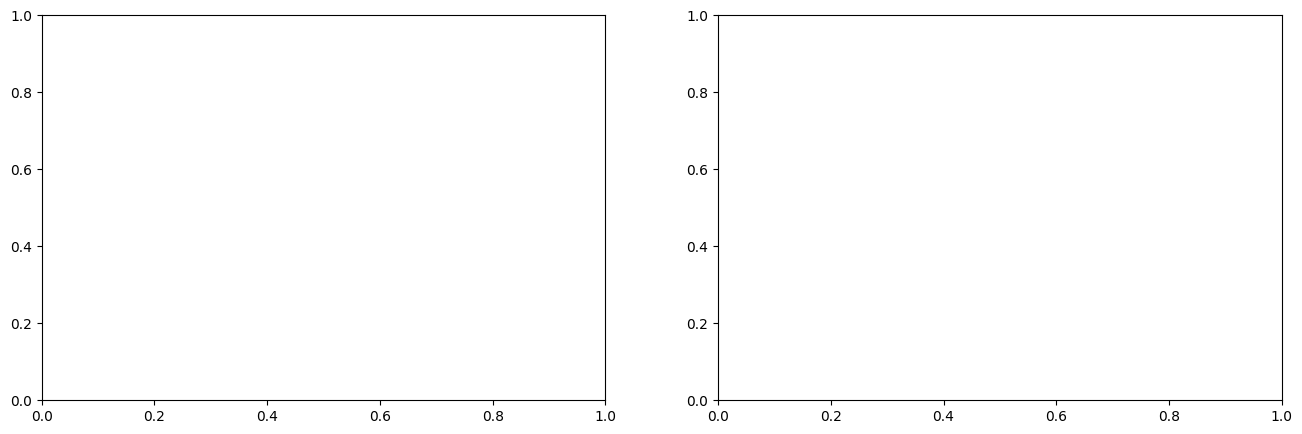

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df = results_df.set_index('instance_id')
plot_df[['routefinder_distance', 'ortools_distance']].plot(kind='bar', ax=axes[0])
axes[0].set_title('RouteFinder vs OR-Tools Distance')
axes[0].set_ylabel('Total distance')
axes[0].grid(axis='y', alpha=0.3)

plot_df['gap_to_ortools_pct'].plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('RouteFinder Gap vs OR-Tools')
axes[1].set_ylabel('Gap (%)')
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'routefinder_vs_ortools_summary.png', dpi=180)
plt.show()
print('Saved summary plot to', OUTPUT_ROOT / 'routefinder_vs_ortools_summary.png')



=== RC201.txt ===
RouteFinder distance: 2994.0
OR-Tools distance: 675.0

=== RC202.txt ===
RouteFinder distance: 3233.0
OR-Tools distance: 605.0

=== RC203.txt ===
RouteFinder distance: 2591.0
OR-Tools distance: 546.0


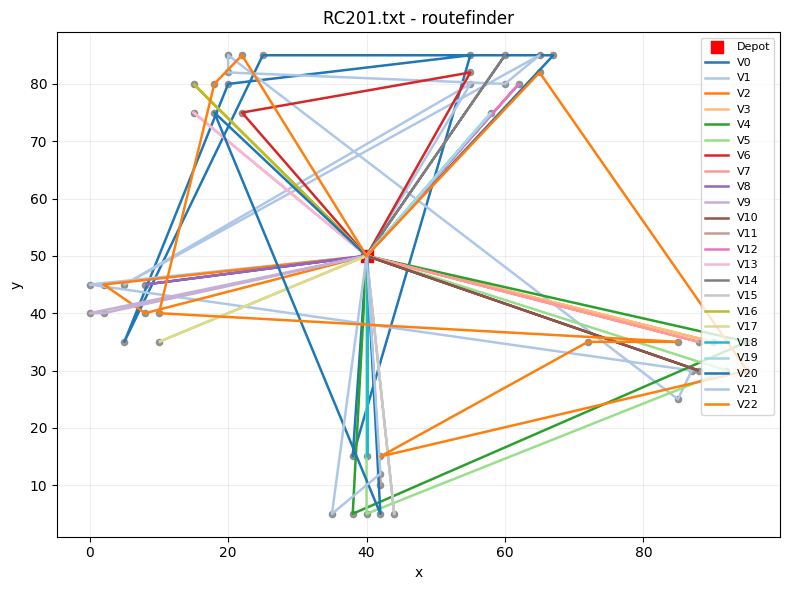

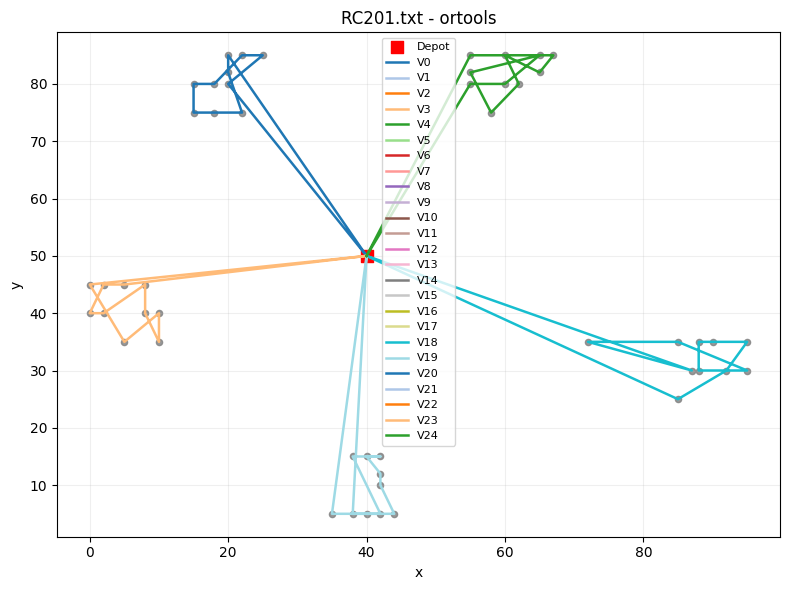

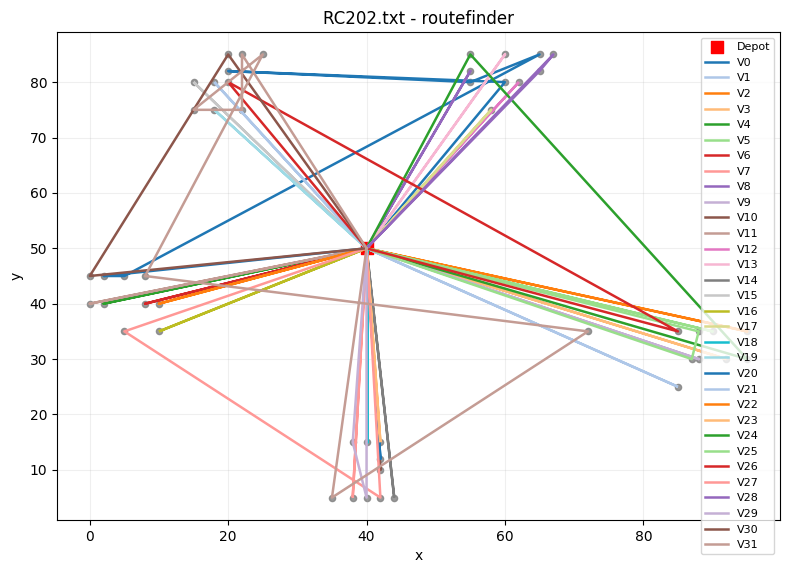

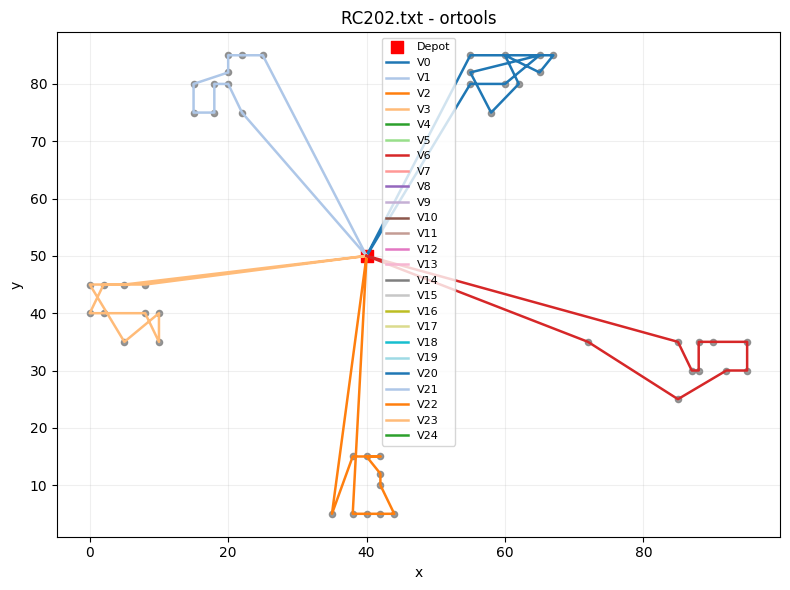

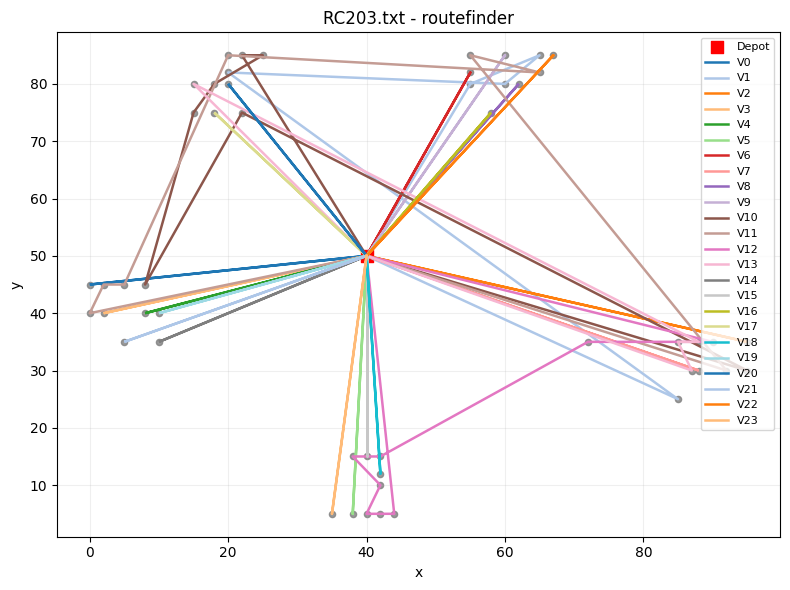

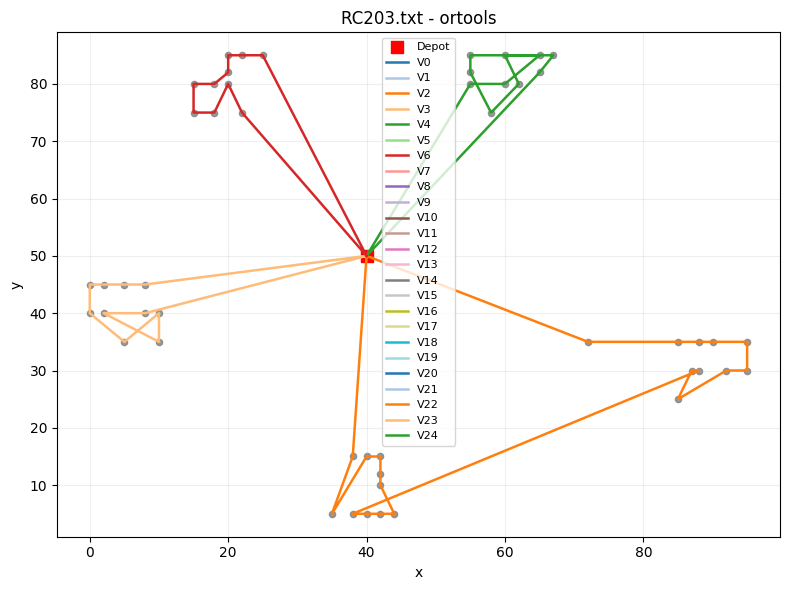

In [ ]:
for instance in instances[: min(3, len(instances))]:
    print(f'\n=== {instance.instance_id} ===')
    print('RouteFinder distance:', routefinder_solutions[instance.instance_id].total_distance)
    print('OR-Tools distance:', ortools_solutions[instance.instance_id].total_distance)
    plot_routes(instance, routefinder_solutions[instance.instance_id])
    plot_routes(instance, ortools_solutions[instance.instance_id])
